# EDA

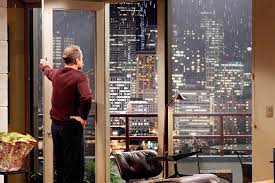

In [133]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from matplotlib.ticker import PercentFormatter
plt.rcParams.update({ "figure.figsize" : (8, 5),"axes.facecolor" : "white", "axes.edgecolor":  "black"})
plt.rcParams["figure.facecolor"]= "w"
pd.plotting.register_matplotlib_converters()
pd.set_option('display.float_format', lambda x: '%.3f' % x)

Loading joint tables

In [134]:
# importing raw data
df_estates = pd.read_csv('data/estates.csv')

In [135]:
# your code: check for data types and statistics overview of data frame columns
df_estates.tail()
#print(f"{df_estates.tail()}")
#df_estates.describe()

,house_id,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
21592,263000018,2014-05-21,360000.000,21593,3.000,2.500,1530.000,1131.000,3.000,0.000,...,8,1530.000,0.000,2009,0.000,98103,47.699,-122.346,1530.000,1509.000
21593,6600060120,2015-02-23,400000.000,21594,4.000,2.500,2310.000,5813.000,2.000,0.000,...,8,2310.000,0.000,2014,0.000,98146,47.511,-122.362,1830.000,7200.000
21594,1523300141,2014-06-23,402101.000,21595,2.000,0.750,1020.000,1350.000,2.000,0.000,...,7,1020.000,0.000,2009,0.000,98144,47.594,-122.299,1020.000,2007.000
21595,291310100,2015-01-16,400000.000,21596,3.000,2.500,1600.000,2388.000,2.000,NaN,...,8,1600.000,0.000,2004,0.000,98027,47.535,-122.069,1410.000,1287.000
21596,1523300157,2014-10-15,325000.000,21597,2.000,0.750,1020.000,1076.000,2.000,0.000,...,7,1020.000,0.000,2008,0.000,98144,47.594,-122.299,1020.000,1357.000


In [136]:
df_estates.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   house_id       21597 non-null  int64  
 1   date           21597 non-null  object 
 2   price          21597 non-null  float64
 3   id             21597 non-null  int64  
 4   bedrooms       21597 non-null  float64
 5   bathrooms      21597 non-null  float64
 6   sqft_living    21597 non-null  float64
 7   sqft_lot       21597 non-null  float64
 8   floors         21597 non-null  float64
 9   waterfront     19206 non-null  float64
 10  view           21534 non-null  float64
 11  condition      21597 non-null  int64  
 12  grade          21597 non-null  int64  
 13  sqft_above     21597 non-null  float64
 14  sqft_basement  21145 non-null  float64
 15  yr_built       21597 non-null  int64  
 16  yr_renovated   17749 non-null  float64
 17  zipcode        21597 non-null  int64  
 18  lat   

In [137]:
# check duplicate lines
df_estates.duplicated().value_counts()

False    21597
Name: count, dtype: int64

In [138]:
df_estates.describe()

,house_id,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,21534.000,...,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,4580474287.771,540296.574,10799.000,3.373,2.116,2080.322,15099.409,1.494,0.008,0.234,...,7.658,1788.597,291.857,1971.000,836.651,98077.952,47.560,-122.214,1986.620,12758.284
std,2876735715.748,367368.140,6234.661,0.926,0.769,918.106,41412.637,0.540,0.087,0.766,...,1.173,827.760,442.491,29.375,4000.111,53.513,0.139,0.141,685.230,27274.442
min,1000102.000,78000.000,1.000,1.000,0.500,370.000,520.000,1.000,0.000,0.000,...,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,2123049175.000,322000.000,5400.000,3.000,1.750,1430.000,5040.000,1.000,0.000,0.000,...,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,3904930410.000,450000.000,10799.000,3.000,2.250,1910.000,7618.000,1.500,0.000,0.000,...,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000
75%,7308900490.000,645000.000,16198.000,4.000,2.500,2550.000,10685.000,2.000,0.000,0.000,...,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,9900000190.000,7700000.000,21597.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,4.000,...,13.000,9410.000,4820.000,2015.000,20150.000,98199.000,47.778,-121.315,6210.000,871200.000


In [139]:
# check data types in data frame
df_estates.dtypes

house_id           int64
date              object
price            float64
id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
dtype: object

In [140]:
# date is object, lets convert it
type(df_estates['date'][0])


str

In [141]:
# change "date" dtype to datetime with format %Y/%m/%d
df_estates['date'] = pd.to_datetime(df_estates['date'], format='%Y-%m-%d')
type(df_estates['date'][0])

pandas._libs.tslibs.timestamps.Timestamp

All columns we need are complete, no need to impute data. (21597 values)

In [142]:
import matplotlib as mpl

In [143]:
df_estates = df_estates.sort_values(by='price')

78000.0 7700000.0
3.3116883116883115e-05


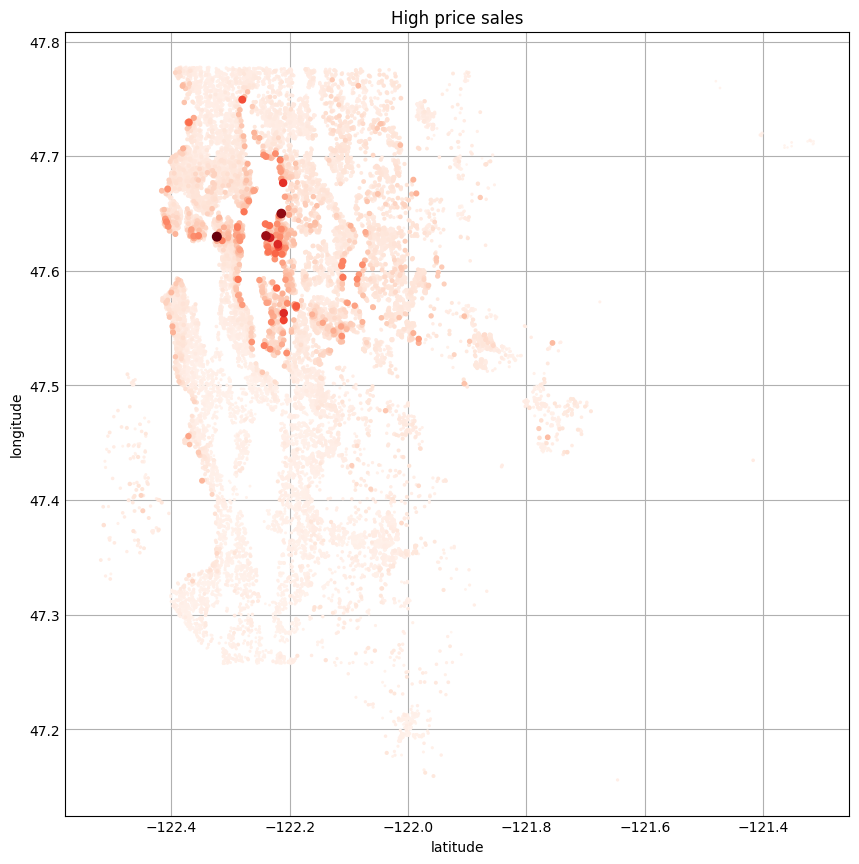

In [201]:
plt.style.use('_mpl-gallery')
# plot
price_max = max(df_estates['price'])
price_min = min(df_estates['price'])
print(price_min, price_max)

factor = 255 / price_max
print(factor)

fig, ax = plt.subplots()

fig.set_figheight(8)
fig.set_figwidth(8)

ax.scatter(df_estates['long'], df_estates['lat'], sizes = df_estates['price']/200000, c = df_estates['price']*factor, cmap="Reds")
plt.title("High price sales")
plt.xlabel("latitude")
plt.ylabel("longitude")
plt.show()

<Axes: >

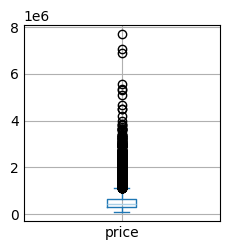

In [145]:
df_estates['price'].plot(kind='box')

<Axes: ylabel='Frequency'>

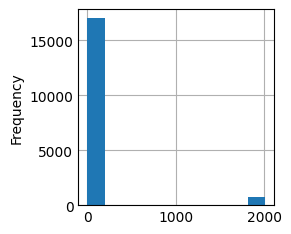

In [147]:
# there are renovation years much too high, we need to find those and divide them by 10
df_estates['yr_renovated'] = df_estates.yr_renovated.apply(lambda x: x/10.0 if x > 2300 else x)
df_estates['yr_renovated'].plot(kind='hist')

In [148]:
# Fixed the max year of yr_renovated
df_estates.describe()

,house_id,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,21597.000,21597,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,21597.000,19206.000,...,21597.000,21597.000,21145.000,21597.000,17749.000,21597.000,21597.000,21597.000,21597.000,21597.000
mean,4580474287.771,2014-10-29 04:20:38.171968512,540296.574,10799.000,3.373,2.116,2080.322,15099.409,1.494,0.008,...,7.658,1788.597,291.857,1971.000,83.665,98077.952,47.560,-122.214,1986.620,12758.284
min,1000102.000,2014-05-02 00:00:00,78000.000,1.000,1.000,0.500,370.000,520.000,1.000,0.000,...,3.000,370.000,0.000,1900.000,0.000,98001.000,47.156,-122.519,399.000,651.000
25%,2123049175.000,2014-07-22 00:00:00,322000.000,5400.000,3.000,1.750,1430.000,5040.000,1.000,0.000,...,7.000,1190.000,0.000,1951.000,0.000,98033.000,47.471,-122.328,1490.000,5100.000
50%,3904930410.000,2014-10-16 00:00:00,450000.000,10799.000,3.000,2.250,1910.000,7618.000,1.500,0.000,...,7.000,1560.000,0.000,1975.000,0.000,98065.000,47.572,-122.231,1840.000,7620.000
75%,7308900490.000,2015-02-17 00:00:00,645000.000,16198.000,4.000,2.500,2550.000,10685.000,2.000,0.000,...,8.000,2210.000,560.000,1997.000,0.000,98118.000,47.678,-122.125,2360.000,10083.000
max,9900000190.000,2015-05-27 00:00:00,7700000.000,21597.000,33.000,8.000,13540.000,1651359.000,3.500,1.000,...,13.000,9410.000,4820.000,2015.000,2015.000,98199.000,47.778,-121.315,6210.000,871200.000
std,2876735715.748,NaN,367368.140,6234.661,0.926,0.769,918.106,41412.637,0.540,0.087,...,1.173,827.760,442.491,29.375,400.011,53.513,0.139,0.141,685.230,27274.442


In [149]:
# missing values in yr_renovated, only 21597 available
df_estates.info()


<class 'pandas.core.frame.DataFrame'>
Index: 21597 entries, 15279 to 7245
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       21597 non-null  int64         
 1   date           21597 non-null  datetime64[ns]
 2   price          21597 non-null  float64       
 3   id             21597 non-null  int64         
 4   bedrooms       21597 non-null  float64       
 5   bathrooms      21597 non-null  float64       
 6   sqft_living    21597 non-null  float64       
 7   sqft_lot       21597 non-null  float64       
 8   floors         21597 non-null  float64       
 9   waterfront     19206 non-null  float64       
 10  view           21534 non-null  float64       
 11  condition      21597 non-null  int64         
 12  grade          21597 non-null  int64         
 13  sqft_above     21597 non-null  float64       
 14  sqft_basement  21145 non-null  float64       
 15  yr_built       21597 

In [150]:
# we replace nan by 0 and check again
df_estates['yr_renovated'] = df_estates['yr_renovated'].fillna(0)
df_estates.info()
# ok that worked now 21597 values!

<class 'pandas.core.frame.DataFrame'>
Index: 21597 entries, 15279 to 7245
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   house_id       21597 non-null  int64         
 1   date           21597 non-null  datetime64[ns]
 2   price          21597 non-null  float64       
 3   id             21597 non-null  int64         
 4   bedrooms       21597 non-null  float64       
 5   bathrooms      21597 non-null  float64       
 6   sqft_living    21597 non-null  float64       
 7   sqft_lot       21597 non-null  float64       
 8   floors         21597 non-null  float64       
 9   waterfront     19206 non-null  float64       
 10  view           21534 non-null  float64       
 11  condition      21597 non-null  int64         
 12  grade          21597 non-null  int64         
 13  sqft_above     21597 non-null  float64       
 14  sqft_basement  21145 non-null  float64       
 15  yr_built       21597 

In [151]:
# graph all sales all prices!

# create a combined line plot to show sale price of not renovated and renovated estates over the year.
df = df_estates.sort_values(by=['date'], ascending=True)

x_year_sale_renov = df.loc[df['yr_renovated'] > 0.1, ['date']]
x_year_sale_unrenov = df.loc[df['yr_renovated'] < 0.1, ['date']]
y_renov = df.loc[df['yr_renovated'] > 0.1, ['price']]
y_unrenov = df.loc[df['yr_renovated'] < 0.1, ['price']]

print(x_year_sale_renov.size)
print(x_year_sale_unrenov.size)
#print(y_renov)
print(y_unrenov.size)

y_unrenov.head()


744
20853
20853


,price
15113,308500.000
20543,295000.000
18675,470000.000
21374,300000.000
9578,675000.000


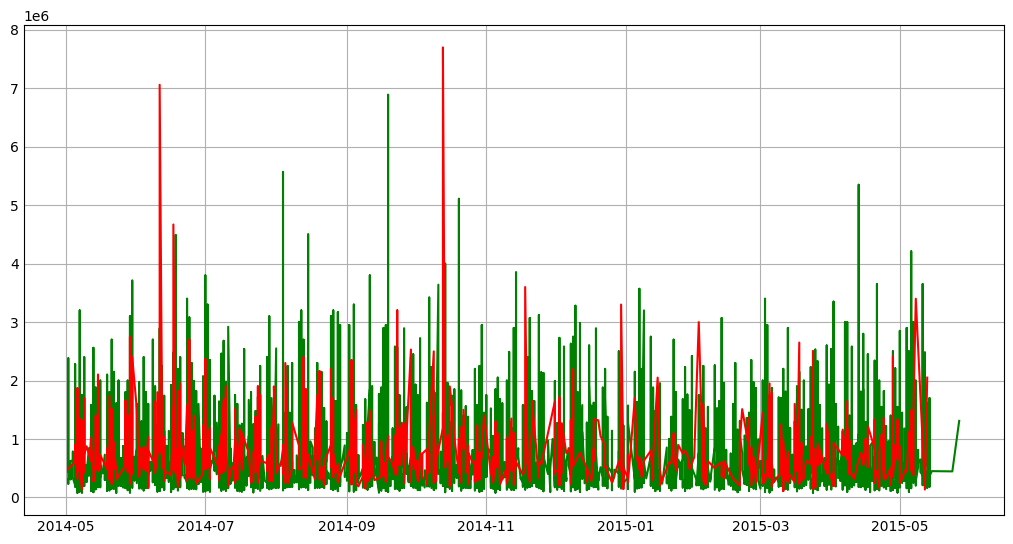

In [152]:
fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(10)

plt.plot(x_year_sale_unrenov, y_unrenov, label = "line 2", color='green')
plt.plot(x_year_sale_renov, y_renov, label = "line 1", color='red')
plt.show()

907664.713606974


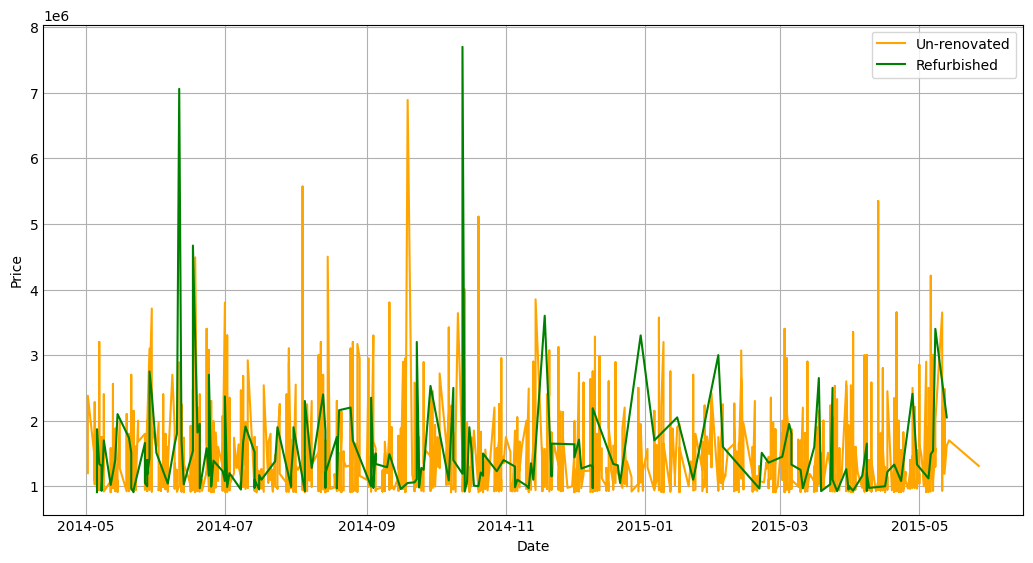

5038    1200000.000
4331    1400000.000
312     2380000.000
16092   1430000.000
11932   1030000.000
Name: price, dtype: float64

In [153]:
# Graph on the top x percent with outliers

# create a combined line plot to show sale price of not renovated and renovated estates over the year.
df_sorted = df_estates.sort_values(by=['date'], ascending=True)

#price_mean = max(df_sorted['price'])/5.0
#print(price_mean)

price_mean = df_sorted['price'].mean() + df_sorted['price'].std() 
print(price_mean)


x_year_sale_renov = df.query('yr_renovated > 0.1 and price > @price_mean')['date']
x_year_sale_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean')['date']
y_renov = df.query('yr_renovated > 0.1 and price > @price_mean')['price']#.rolling(15).mean()
y_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean')['price']#.rolling(15).mean()

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(10)

plt.plot(x_year_sale_unrenov, y_unrenov, label = "line 2", color='orange')
plt.plot(x_year_sale_renov, y_renov, label = "line 1", color='green')
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend(['Un-renovated','Refurbished'])
plt.show()

y_unrenov.head()



540296.5735055795


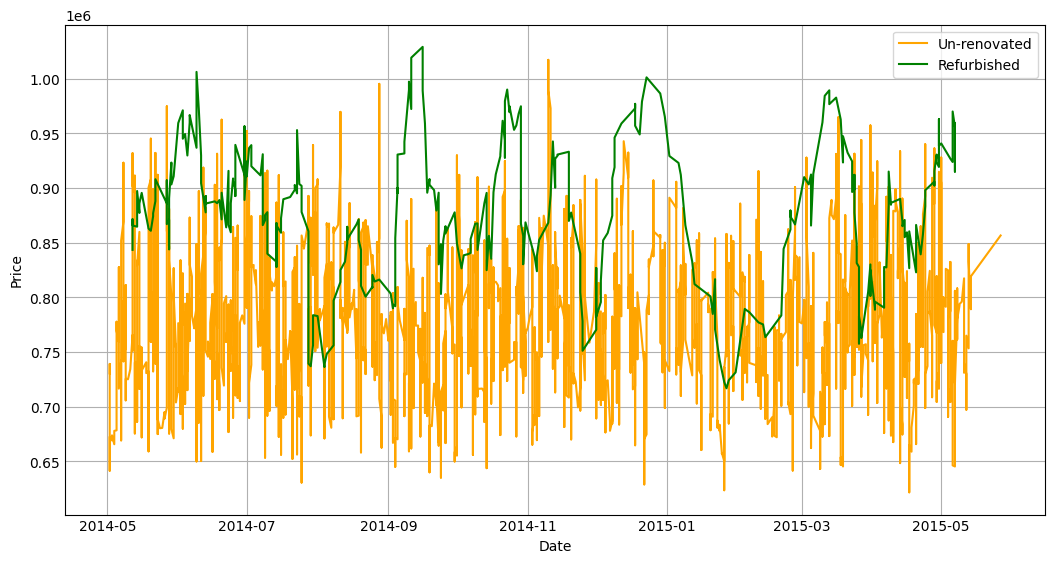

9578    NaN
5038    NaN
19661   NaN
4331    NaN
8319    NaN
Name: price, dtype: float64

In [154]:
# Graph, remove top outliers price range > mean smoothed

# create a combined line plot to show sale price of not renovated and renovated estates over the year.
df_sorted = df_estates.sort_values(by=['date'], ascending=True)

#price_mean = max(df_sorted['price'])/5.0
#print(price_mean)

price_mean = df_sorted['price'].mean() #+ df_sorted['price'].std() 
print(price_mean)
price_max = df_sorted['price'].mean() + 3*df_sorted['price'].std()


x_year_sale_renov = df.query('yr_renovated > 0.1 and price > @price_mean and price < @price_max')['date']
x_year_sale_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean and price < @price_max')['date']
y_renov = df.query('yr_renovated > 0.1 and price > @price_mean and price < @price_max')['price'].rolling(15).mean()
y_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean and price < @price_max')['price'].rolling(15).mean()

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(10)

plt.plot(x_year_sale_unrenov, y_unrenov, label = "line 2", color='orange')
plt.plot(x_year_sale_renov, y_renov, label = "line 1", color='green')
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend(['Un-renovated','Refurbished'])
plt.show()

y_unrenov.head()


907664.713606974


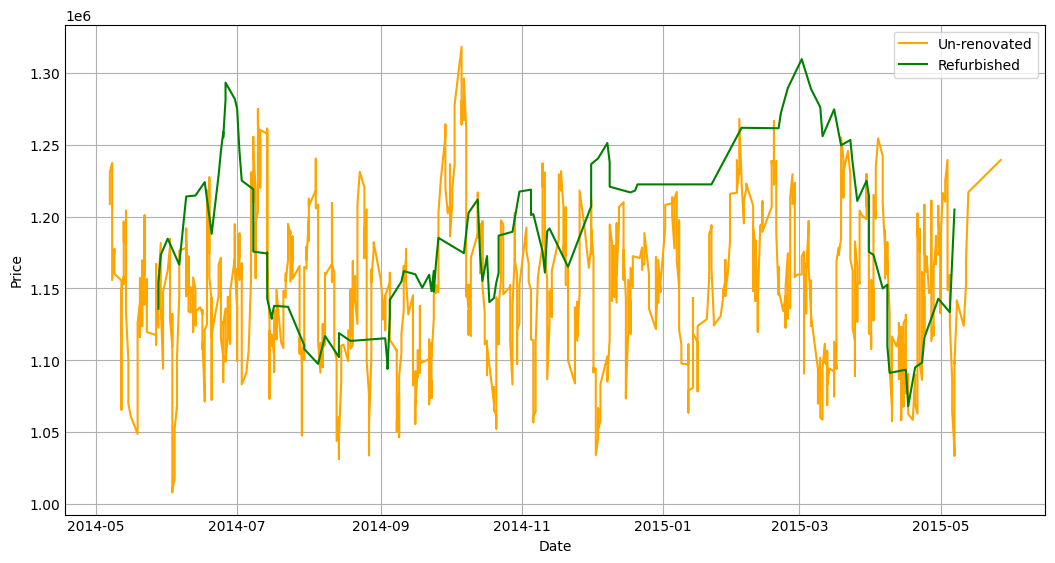

5038    NaN
4331    NaN
16092   NaN
11932   NaN
6953    NaN
Name: price, dtype: float64

In [155]:
# Graph, remove top outliers price range > upper quantile smoothed

# create a combined line plot to show sale price of not renovated and renovated estates over the year.
df_sorted = df_estates.sort_values(by=['date'], ascending=True)

#price_mean = max(df_sorted['price'])/5.0
#print(price_mean)

price_mean = df_sorted['price'].mean() + df_sorted['price'].std() 
print(price_mean)
price_max = df_sorted['price'].mean() + 3*df_sorted['price'].std()


x_year_sale_renov = df.query('yr_renovated > 0.1 and price > @price_mean and price < @price_max')['date']
x_year_sale_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean and price < @price_max')['date']
y_renov = df.query('yr_renovated > 0.1 and price > @price_mean and price < @price_max')['price'].rolling(15).mean()
y_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean and price < @price_max')['price'].rolling(15).mean()

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(10)

plt.plot(x_year_sale_unrenov, y_unrenov, label = "line 2", color='orange')
plt.plot(x_year_sale_renov, y_renov, label = "line 1", color='green')
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend(['Un-renovated','Refurbished'])
plt.show()

y_unrenov.head()

907664.713606974


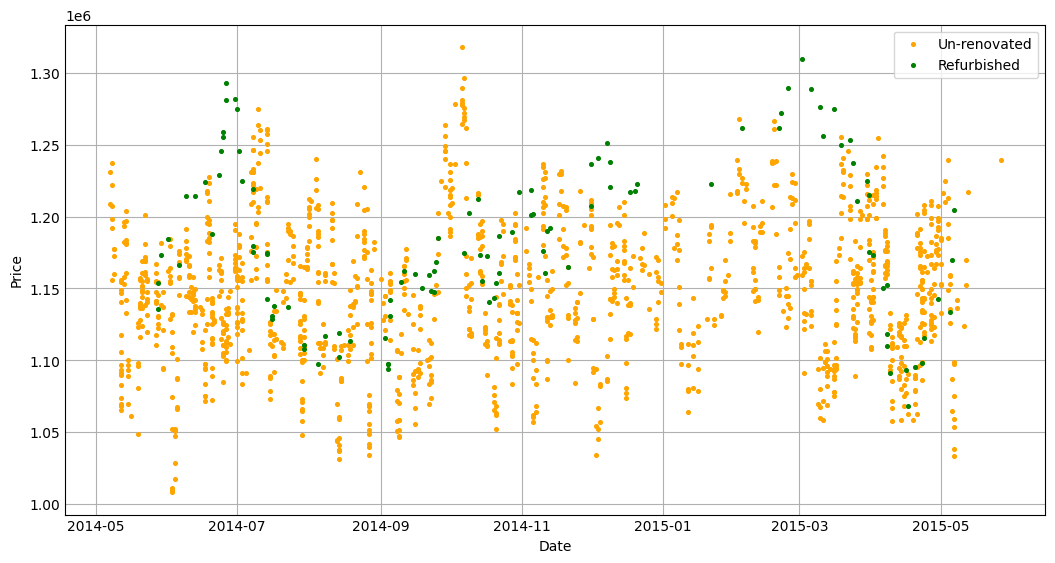

5038    NaN
4331    NaN
16092   NaN
11932   NaN
6953    NaN
Name: price, dtype: float64

In [156]:
# Graph, remove top outliers price range > upper quantile smoothed

# create a combined line plot to show sale price of not renovated and renovated estates over the year.
df_sorted = df_estates.sort_values(by=['date'], ascending=True)

#price_mean = max(df_sorted['price'])/5.0
#print(price_mean)

price_mean = df_sorted['price'].mean() + df_sorted['price'].std() 
print(price_mean)
price_max = df_sorted['price'].mean() + 3*df_sorted['price'].std()


x_year_sale_renov = df.query('yr_renovated > 0.1 and price > @price_mean and price < @price_max')['date']
x_year_sale_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean and price < @price_max')['date']
y_renov = df.query('yr_renovated > 0.1 and price > @price_mean and price < @price_max')['price'].rolling(15).mean()
y_unrenov = df.query('yr_renovated < 0.1 and price > @price_mean and price < @price_max')['price'].rolling(15).mean()

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(10)

ax.scatter(x_year_sale_unrenov, y_unrenov, label = "line 2", color='orange', s = 7)
ax.scatter(x_year_sale_renov, y_renov, label = "line 1", color='green', s = 7)
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend(['Un-renovated','Refurbished'])
plt.show()

y_unrenov.head()

540296.5735055795
-122.19983015088798
47.619049432501


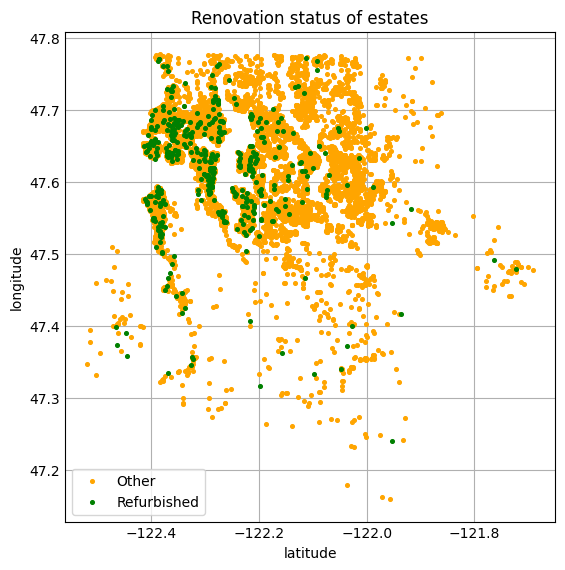

In [157]:
# select all expensive sales, visualize location
price_top = df_sorted['price'].mean()# + 3*df_sorted['price'].std() 
print(price_top)

long_top_price = df_sorted.query('yr_renovated < 0.1 and price > @price_top')['long']#.rolling(15).mean()
lat_top_price = df_sorted.query('yr_renovated < 0.1 and price > @price_top')['lat']#.rolling(15).mean()

long_top_price_r = df_sorted.query('yr_renovated > 0.1 and price > @price_top')['long']#.rolling(15).mean()
lat_top_price_r = df_sorted.query('yr_renovated > 0.1 and price > @price_top')['lat']#.rolling(15).mean()

print(long_top_price.mean())
print(lat_top_price.mean())

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(5)
ax.scatter(long_top_price, lat_top_price, label = "line 2", color='orange', s = 7)
ax.scatter(long_top_price_r, lat_top_price_r, label = "line 2", color='green', s = 7)
ax.legend(['Other','Refurbished'])
plt.title("Renovation status of estates")
plt.xlabel("latitude")
plt.ylabel("longitude")
plt.show()



-122.21607619047619
47.60653571428572
210
37


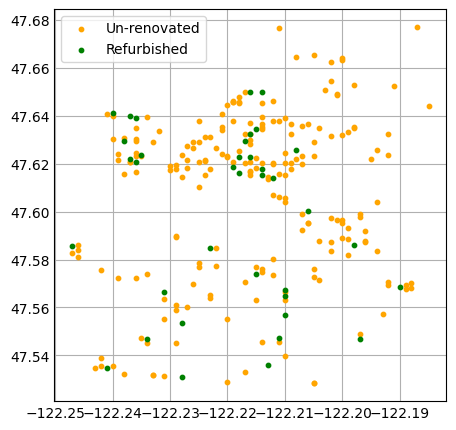

In [172]:
# select only estates in center
price_mean = df_sorted['price'].mean()
df_center = df_estates.query('price > @price_mean and lat > 47.52 and lat < 47.68 and long < -122.18 and long > -122.25')

price_top = df_center['price'].mean() - df_center['price'].std() 

long_top_price = df_center.query('yr_renovated < 0.1 and price > @price_top')['long']#.rolling(15).mean()
lat_top_price = df_center.query('yr_renovated < 0.1 and price > @price_top')['lat']#.rolling(15).mean()

long_top_price_r = df_center.query('yr_renovated > 0.1 and price > @price_top')['long']#.rolling(15).mean()
lat_top_price_r = df_center.query('yr_renovated > 0.1 and price > @price_top')['lat']#.rolling(15).mean()

print(long_top_price.mean())
print(lat_top_price.mean())
print(long_top_price.size)
print(long_top_price_r.size)

fig, ax = plt.subplots()
fig.set_figheight(4)
fig.set_figwidth(4)
ax.scatter(long_top_price, lat_top_price, label = "line 2", color='orange', s = 10)
ax.scatter(long_top_price_r, lat_top_price_r, label = "line 2", color='green', s = 10)
ax.legend(['Un-renovated','Refurbished'])
plt.show()




In [159]:
df_center.describe()

,house_id,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,384.000,384,384.000,384.000,384.000,384.000,384.000,384.000,384.000,341.000,...,384.000,384.000,380.000,384.000,384.000,384.000,384.000,384.000,384.000,384.000
mean,4783350397.635,2014-11-03 04:48:45,1416816.393,10808.357,3.852,2.633,3025.896,13528.779,1.444,0.009,...,8.812,2504.812,524.332,1972.508,192.419,98016.115,47.635,-122.208,2742.786,13101.979
min,249000115.000,2014-05-05 00:00:00,545000.000,70.000,1.000,1.000,860.000,1108.000,1.000,0.000,...,6.000,820.000,0.000,1902.000,0.000,98004.000,47.600,-122.241,1150.000,1160.000
25%,2025059188.250,2014-07-25 00:00:00,824750.000,5142.250,3.000,2.000,2067.500,8658.000,1.000,0.000,...,8.000,1557.500,0.000,1953.000,0.000,98004.000,47.621,-122.218,2100.000,9084.500
50%,4122500097.500,2014-10-25 12:00:00,1165000.000,11135.000,4.000,2.500,2780.000,11338.500,1.000,0.000,...,9.000,2150.000,0.000,1968.000,0.000,98004.000,47.633,-122.206,2660.000,11337.000
75%,8062375068.750,2015-02-25 06:00:00,1715000.000,16366.000,4.000,3.250,3895.000,16745.000,2.000,0.000,...,10.000,3300.000,1000.000,1990.250,0.000,98033.000,47.649,-122.196,3340.000,16254.500
max,9809000020.000,2015-05-13 00:00:00,7060000.000,21585.000,8.000,7.750,10040.000,47502.000,3.000,1.000,...,13.000,8860.000,3000.000,2014.000,2014.000,98039.000,47.680,-122.182,5500.000,44584.000
std,3063900339.092,NaN,880616.958,6352.771,0.946,1.016,1407.986,7511.536,0.515,0.094,...,1.535,1250.397,657.505,23.241,590.048,15.243,0.019,0.015,771.795,6523.947


2135668.016194332


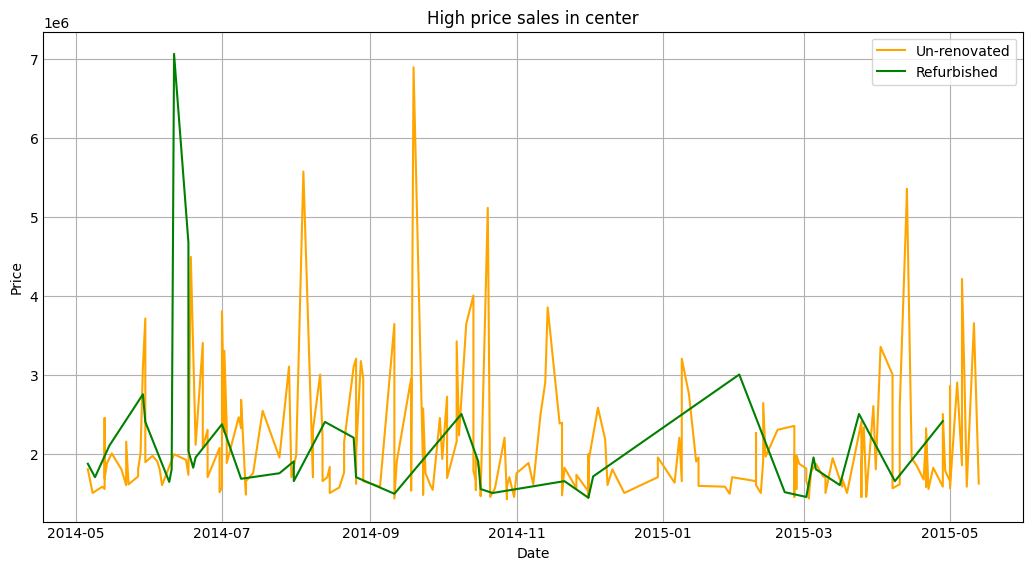

21132   1800000.000
12006   1500000.000
3522    1580000.000
16106   1550000.000
4917    1900000.000
Name: price, dtype: float64

In [173]:
price_mean = df_sorted['price'].mean()
df_center = df_estates.query('price > @price_mean and lat > 47.52 and lat < 47.68 and long < -122.18 and long > -122.25')
df_sorted = df_center.sort_values(by=['date'], ascending=True)
#price_mean = max(df_sorted['price'])/5.0
#print(price_mean)

price_mean = df_sorted['price'].mean()# + df_sorted['price'].std() 
print(price_mean)

x_year_sale_renov = df_sorted.query('yr_renovated > 0.1')['date']
x_year_sale_unrenov = df_sorted.query('yr_renovated < 0.1')['date']
y_renov = df_sorted.query('yr_renovated > 0.1')['price']#.rolling(3).mean()
y_unrenov = df_sorted.query('yr_renovated < 0.1')['price']#.rolling(3).mean()

fig, ax = plt.subplots()
fig.set_figheight(5)
fig.set_figwidth(10)

plt.title("High price sales in center")
plt.plot(x_year_sale_unrenov, y_unrenov, label = "line 2", color='orange')
plt.plot(x_year_sale_renov, y_renov, label = "line 1", color='green')
ax.set_ylabel('Price')
ax.set_xlabel('Date')
ax.legend(['Un-renovated','Refurbished'])
plt.show()

y_unrenov.head()

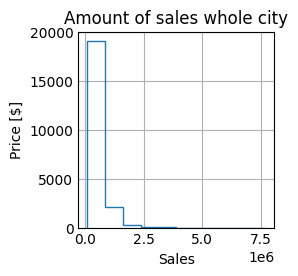

In [200]:
# hist of sales all
counts, bins = np.histogram(df_estates['price'])
plt.stairs(counts, bins)
plt.title("Amount of sales whole city")
plt.xlabel("Sales")
plt.ylabel("Price [$]")
plt.show()

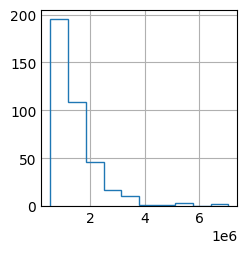

In [161]:
# hist of expensive sales in center
counts, bins = np.histogram(df_center['price'])
plt.stairs(counts, bins)

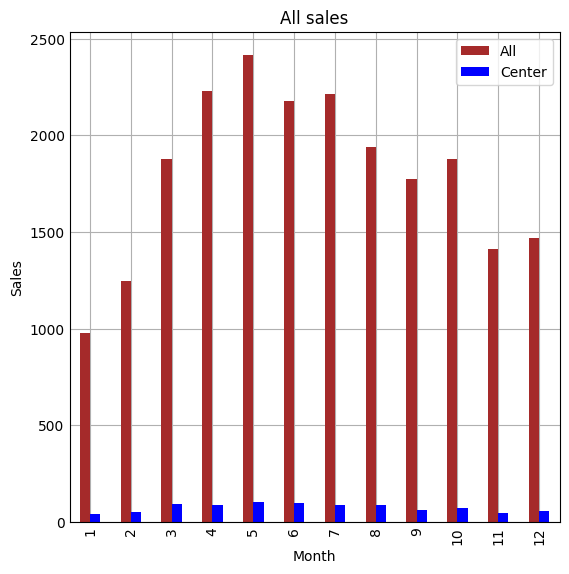

In [188]:
# prepare boxplot for sales each month: all objects
df_estates['month'] = df_estates['date'].dt.month
sale_month_all = df_estates['month'].value_counts()
a1 = sale_month_all.sort_index()

# prepare bar plot for sales each month: center only
df_center_all = df_estates.query('lat > 47.52 and lat < 47.68 and long < -122.18 and long > -122.25')
df_center_all['month'] = df_center_all['date'].dt.month
sale_month_exp = df_center_all['month'].value_counts()
a2 = sale_month_exp.sort_index()

df = pd.DataFrame ({'All':a1, 'Center':a2})
ax = df.plot.bar(xlabel='Month', ylabel='Sales', figsize=(5,5), color=['brown','blue'], title="All sales")


In [179]:
price_mean = df_estates['price'].mean()
df_center = df_estates.query('price > @price_mean and lat > 47.52 and lat < 47.68 and long < -122.18 and long > -122.25')
renov = df_center.query('yr_renovated > 0.1')['date'].dt.month
s1 = renov.value_counts().sort_index()

unrenov = df_center.query('yr_renovated < 0.1')['date'].dt.month
s2 = unrenov.value_counts().sort_index()

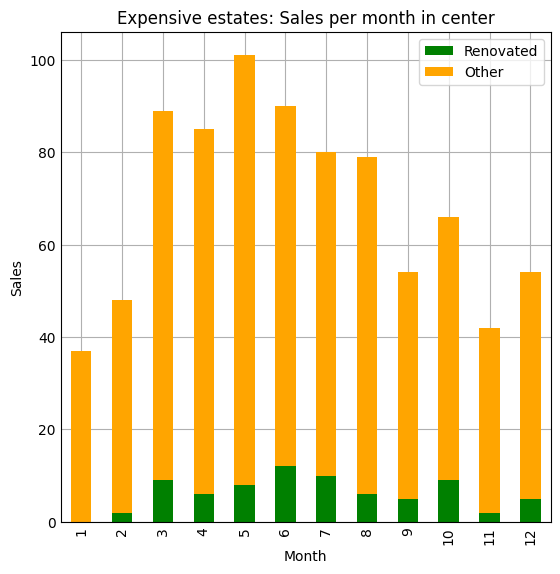

In [180]:
# create data
df = pd.DataFrame ({'Renovated':s1, 'Other':s2})

ax = df.plot.bar(xlabel='Month', ylabel='Sales', stacked=True, figsize=(5,5), color=['green','orange'], title="Expensive estates: Sales per month in center")



74 751


<Axes: title={'center': 'Amount of center estate sales: 2014-05 to 2015-05'}>

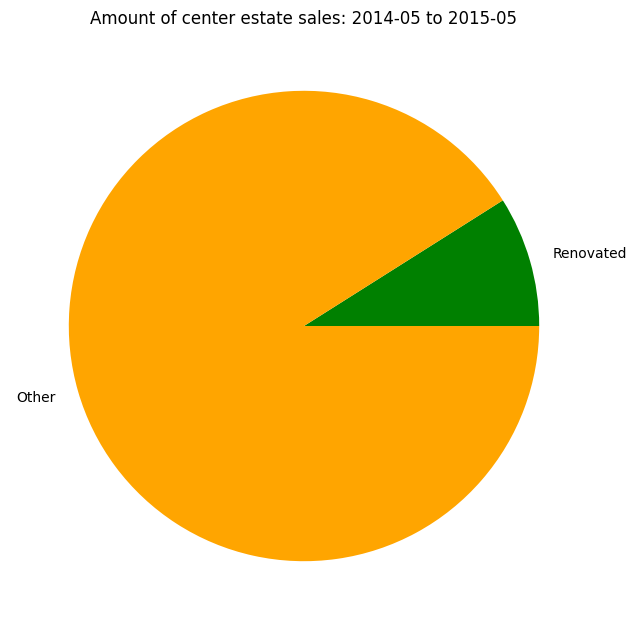

In [181]:
# pie chart
print(s1.sum(), s2.sum())
series = pd.Series([s1.sum(), s2.sum()], index=["Renovated", "Other"])
series.plot.pie(figsize=(6, 6),colors=['green','orange'], title="Amount of center estate sales: 2014-05 to 2015-05")

In [182]:
df_center.describe()

,house_id,date,price,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,month
count,825.000,825,825.000,825.000,825.000,825.000,825.000,825.000,825.000,728.000,...,825.000,812.000,825.000,825.000,825.000,825.000,825.000,825.000,825.000,825.000
mean,4313848306.213,2014-10-28 07:28:34.909090816,1275112.561,10647.462,3.926,2.686,3051.097,13386.728,1.501,0.026,...,2509.773,543.869,1974.354,179.147,98024.201,47.596,-122.211,2782.201,12585.544,6.343
min,31000165.000,2014-05-05 00:00:00,541125.000,22.000,1.000,1.000,860.000,1108.000,1.000,0.000,...,820.000,0.000,1902.000,0.000,98004.000,47.520,-122.249,1150.000,1160.000,1.000
25%,2162000260.000,2014-07-14 00:00:00,789800.000,4920.000,3.000,2.000,2190.000,8944.000,1.000,0.000,...,1650.000,0.000,1958.000,0.000,98004.000,47.561,-122.224,2280.000,9436.000,4.000
50%,3861400030.000,2014-10-15 00:00:00,1000000.000,10968.000,4.000,2.500,2876.000,11250.000,1.500,0.000,...,2260.000,0.000,1970.000,0.000,98033.000,47.592,-122.211,2740.000,11212.000,6.000
75%,6071200545.000,2015-02-25 00:00:00,1570000.000,16107.000,4.000,3.250,3740.000,16100.000,2.000,0.000,...,3180.000,1002.500,1991.000,0.000,98040.000,47.631,-122.197,3260.000,15263.000,9.000
max,9809000020.000,2015-05-13 00:00:00,7060000.000,21585.000,8.000,7.750,10040.000,92347.000,3.000,1.000,...,8860.000,4820.000,2015.000,2014.000,98059.000,47.680,-122.181,5500.000,44584.000,12.000
std,2743268276.677,NaN,756523.038,6278.529,0.882,0.936,1263.942,7723.616,0.519,0.160,...,1104.606,665.582,22.183,571.064,18.121,0.042,0.017,694.559,5386.957,3.071


,Renovated,Other
1,NaN,45090841.000
2,4510000.000,55208239.000
3,12805000.000,91731338.000
4,8625000.000,102564152.000
5,13435650.000,123510254.000
6,26221900.000,93076876.000
7,14403400.000,84969100.000
8,8779560.000,92132838.000
9,5140000.000,62606500.000
10,12415000.000,80058050.000


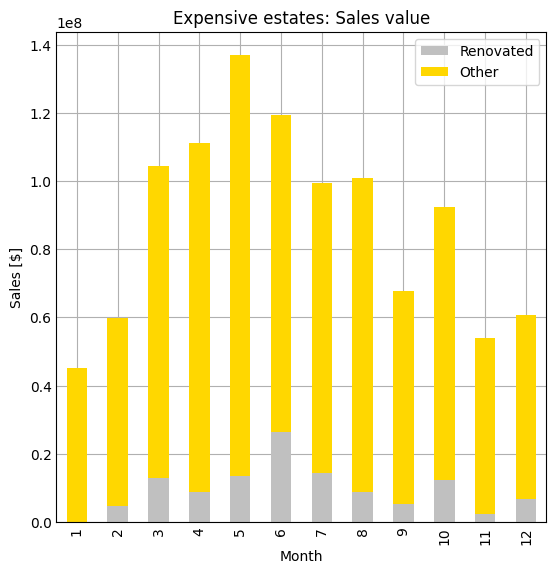

In [229]:
# extract value of renovated and unrenovated sales per month
price_mean = df_estates['price'].mean() #+ 1*df_sorted['price'].std() 
df_center = df_estates.query('price > @price_mean and lat > 47.52 and lat < 47.68 and long < -122.18 and long > -122.25')

renov = df_center.query('yr_renovated > 0.1')['date'].dt.month
price = df_center.query('yr_renovated > 0.1')['price']
df = pd.DataFrame ({'renov':renov, 'Renovated':price})
dff_renov = df.groupby(["renov"]).Renovated.sum().reset_index()
dff_renov = dff_renov.set_index('renov') 


unrenov = df_center.query('yr_renovated < 0.1')['date'].dt.month
unprice = df_center.query('yr_renovated < 0.1')['price']
df = pd.DataFrame ({'unrenov':unrenov, 'Other':unprice})
dff_unrenov = df.groupby(["unrenov"]).Other.sum().reset_index()
dff_unrenov = dff_unrenov.set_index('unrenov')

res = pd.concat([dff_renov, dff_unrenov], axis=1)
res_sorted = res.sort_index()

ax = res_sorted.plot.bar(xlabel='Month', ylabel='Sales [$]', stacked=True, figsize=(5,5), color=['silver','gold'], title="Expensive estates: Sales value")

res_sorted


115312410.0 936655453.0


<Axes: title={'center': 'Value of center estate sales: 2014-05 to 2015-05'}>

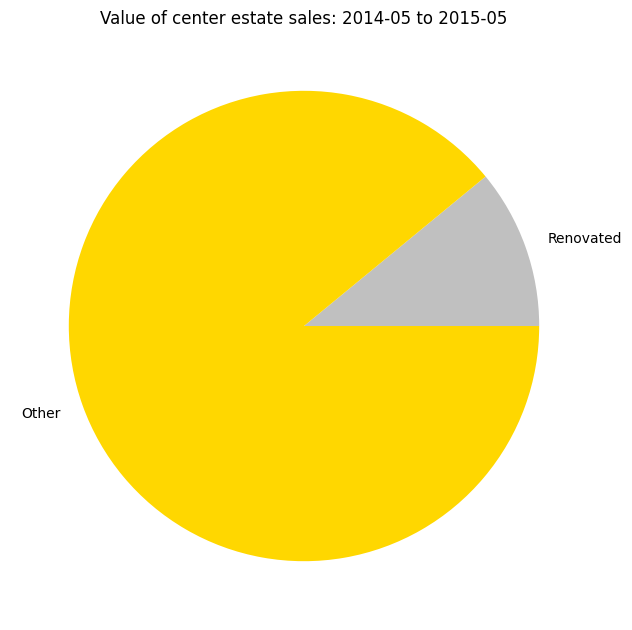

In [186]:
# pie chart
print(price.sum(), unprice.sum())
series = pd.Series([price.sum(), unprice.sum()], index=["Renovated", "Other"], )
series.plot.pie(figsize=(6, 6),colors=['silver','gold'], title="Value of center estate sales: 2014-05 to 2015-05")

,Renovated,Other
2,4510000.000,55208239.000
3,12805000.000,91731338.000
4,8625000.000,102564152.000
5,13435650.000,123510254.000
6,26221900.000,93076876.000


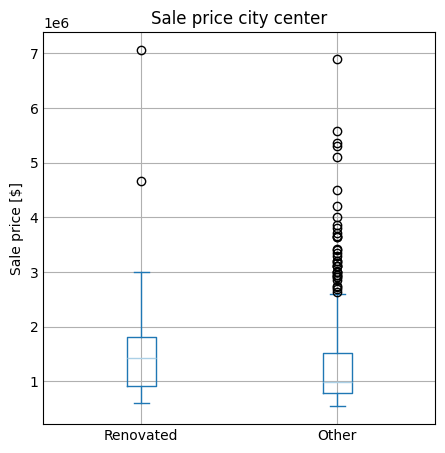

In [223]:
prices = pd.DataFrame ({'Renovated':price, 'Other':unprice})
prices.plot(ylabel='Sale price [$]', kind='box',title='Sale price city center', figsize=(4,4))
res.head()